# Chapter 12: Reading & Writing Natural Languages

In [85]:
from collections import Counter, defaultdict
from random import randint
import re
import string

import nltk
from nltk import word_tokenize, Text, FreqDist, bigrams, ngrams, pos_tag, sent_tokenize
import requests

## Summarizing data

In [2]:
def replace_newlines(text: str) -> str:
    return text.replace("\n", " ")


def make_lowercase(text: str) -> str:
    return text.lower()


def split_sentences(text: str) -> list:
    return [s.strip() for s in text.split(". ")]

In [3]:
puncts = [re.escape(c) for c in string.punctuation]
PUNCTUATION_REGEX = re.compile("|".join(puncts))

def remove_punctuation(text: str) -> str:
    return re.sub(PUNCTUATION_REGEX, "", text)

In [4]:
url = "https://pythonscraping.com/files/inaugurationSpeech.txt"
resp = requests.get(url)
print(resp)

<Response [200]>


In [5]:
content = resp.text
content[:3000]

'Called from a retirement which I had supposed was to continue for the residue of my life to fill the chief executive office of this great and free nation, I appear before you, fellow-citizens, to take the oaths which the Constitution prescribes as a necessary qualification for the performance of its duties; and in obedience to a custom coeval with our Government and what I believe to be your expectations I proceed to present to you a summary of the principles which will govern me in the discharge of the duties which I shall be called upon to perform.\n\nIt was the remark of a Roman consul in an early period of that celebrated Republic that a most striking contrast was observable in the conduct of candidates for offices of power and trust before and after obtaining them, they seldom carrying out in the latter case the pledges and promises made in the former. However much the world may have improved in many respects in the lapse of upward of two thousand years since the remark was made 

In [6]:
text_operations = [
    replace_newlines,
    split_sentences,
    make_lowercase,
    remove_punctuation
]

for t_op in text_operations:
    if isinstance(content, list):
        content = [t_op(c) for c in content]
    else:
        content = t_op(content)

print(content)

['called from a retirement which i had supposed was to continue for the residue of my life to fill the chief executive office of this great and free nation i appear before you fellowcitizens to take the oaths which the constitution prescribes as a necessary qualification for the performance of its duties and in obedience to a custom coeval with our government and what i believe to be your expectations i proceed to present to you a summary of the principles which will govern me in the discharge of the duties which i shall be called upon to perform', 'it was the remark of a roman consul in an early period of that celebrated republic that a most striking contrast was observable in the conduct of candidates for offices of power and trust before and after obtaining them they seldom carrying out in the latter case the pledges and promises made in the former', 'however much the world may have improved in many respects in the lapse of upward of two thousand years since the remark was made by t

In [7]:
def getNgrams(text: str, n: int) -> list:
    text = text.split(" ")
    return [" ".join(text[i:i+n]) for i in range(len(text)-n+1)]


def countNGramsFromSentences(sentences: list, n: int) -> Counter:
    counts = Counter()
    for sentence in sentences:
        counts.update(getNgrams(sentence, n))
    return counts

In [8]:
counts = countNGramsFromSentences(content, 2)
counts

Counter({'of the': 213,
         'in the': 65,
         'to the': 61,
         'by the': 41,
         'the constitution': 34,
         'of our': 29,
         'to be': 26,
         'the people': 24,
         'from the': 24,
         'that the': 23,
         'and the': 23,
         'it is': 23,
         'of a': 22,
         'may be': 19,
         'of their': 19,
         'the executive': 19,
         'of that': 18,
         'for the': 16,
         'of its': 16,
         'of power': 16,
         'have been': 16,
         'is the': 16,
         'with the': 15,
         'the government': 15,
         'all the': 15,
         'which they': 13,
         'has been': 13,
         'there is': 13,
         'power to': 12,
         'the power': 11,
         'that of': 11,
         'as to': 11,
         'their own': 11,
         'the same': 11,
         'spirit of': 11,
         'which the': 10,
         'but the': 10,
         'which it': 10,
         'upon the': 10,
         'can be': 10,
        

In [9]:
counts.most_common()

[('of the', 213),
 ('in the', 65),
 ('to the', 61),
 ('by the', 41),
 ('the constitution', 34),
 ('of our', 29),
 ('to be', 26),
 ('the people', 24),
 ('from the', 24),
 ('that the', 23),
 ('and the', 23),
 ('it is', 23),
 ('of a', 22),
 ('may be', 19),
 ('of their', 19),
 ('the executive', 19),
 ('of that', 18),
 ('for the', 16),
 ('of its', 16),
 ('of power', 16),
 ('have been', 16),
 ('is the', 16),
 ('with the', 15),
 ('the government', 15),
 ('all the', 15),
 ('which they', 13),
 ('has been', 13),
 ('there is', 13),
 ('power to', 12),
 ('the power', 11),
 ('that of', 11),
 ('as to', 11),
 ('their own', 11),
 ('the same', 11),
 ('spirit of', 11),
 ('which the', 10),
 ('but the', 10),
 ('which it', 10),
 ('upon the', 10),
 ('can be', 10),
 ('the united', 10),
 ('united states', 10),
 ('of all', 10),
 ('as the', 10),
 ('part of', 10),
 ('the character', 10),
 ('of liberty', 10),
 ('of my', 9),
 ('to a', 9),
 ('it was', 9),
 ('the great', 9),
 ('on the', 9),
 ('of any', 9),
 ('the pre

In [10]:
COMMON_WORDS = [
    "the",
    "be",
    "and",
    "of",
    "a",
    "in",
    "to",
    "have",
    "it",
    "i",
    "that",
    "for",
    "you",
    "he",
    "with",
    "on",
    "do",
    "say",
    "this",
    "they",
    "is",
    "an",
    "at",
    "but",
    "we",
    "his",
    "from",
    "that",
    "not",
    "by",
    "she",
    "or",
    "as",
    "what",
    "go",
    "their",
    "can",
    "who",
    "get",
    "if",
    "would",
    "her",
    "all",
    "my",
    "make",
    "about",
    "know",
    "will",
    "as",
    "up",
    "one",
    "time",
    "has",
    "been",
    "there",
    "year",
    "so",
    "think",
    "when",
    "which",
    "them",
    "some",
    "me",
    "people",
    "take",
    "out",
    "into",
    "just",
    "see",
    "him",
    "your",
    "come",
    "could",
    "now",
    "than",
    "like",
    "other",
    "how",
    "then",
    "its",
    "our",
    "two",
    "more",
    "these",
    "want",
    "way",
    "look",
    "first",
    "also",
    "new",
    "because",
    "day",
    "more",
    "use",
    "no",
    "man",
    "find",
    "here",
    "thing",
    "give",
    "many",
    "well",
]

In [11]:
def isCommon(ngram: str) -> bool:
    return any([w in COMMON_WORDS for w in ngram.split(" ")])


def filterCommon(counts: dict) -> Counter:
    return Counter({
        key: val for key, val in counts.items() if not isCommon(key)
    })

In [12]:
filterCommon(counts).most_common()

[('united states', 10),
 ('executive department', 4),
 ('general government', 4),
 ('called upon', 3),
 ('chief magistrate', 3),
 ('legislative body', 3),
 ('same causes', 3),
 ('government should', 3),
 ('whole country', 3),
 ('was observable', 2),
 ('express grant', 2),
 ('several departments', 2),
 ('american citizen', 2),
 ('was intended', 2),
 ('are attributable', 2),
 ('upon another', 2),
 ('reserved rights', 2),
 ('federal government', 2),
 ('increase itself', 2),
 ('were made', 2),
 ('heretofore given', 2),
 ('pristine health', 2),
 ('second term', 2),
 ('observed however', 2),
 ('foreign relations', 2),
 ('executive power', 2),
 ('negative upon', 2),
 ('declare void', 2),
 ('both houses', 2),
 ('used only', 2),
 ('state governments', 2),
 ('immediate representatives', 2),
 ('veto power', 2),
 ('high office', 2),
 ('disputed points', 2),
 ('respectively claim', 2),
 ('reserved powers', 2),
 ('state authorities', 2),
 ('great increase', 2),
 ('elective franchise', 2),
 ('strange

## Markov models

In [13]:
def retrieveRandomWord(wordList: dict) -> str:
    randIdx = randint(1, sum(wordList.values()))
    for word, value in wordList.items():
        randIdx -= value
        if randIdx <= 0:
            return word


def cleanAndSplitText(text: str) -> list:
    # remove newlines and quotes
    text = text.replace("\n", " ").replace('"', '')
    # make sure punctation marks as treated as their own "words",
    # so that they will be included in Markov chain
    punctuation = [",", ".", ";", ":"]
    for symbol in punctuation:
        text = text.replace(symbol, f" {symbol} ")
    # filter out empty words
    return [word for word in text.split(" ") if word != ""]


def buildWordDict(text: str) -> defaultdict:
    words = cleanAndSplitText(text)
    wordDict = defaultdict(dict)
    for i in range(1, len(words)):
        wordDict[words[i-1]][words[i]] = wordDict[words[i-1]].get(words[i], 0) + 1
    return wordDict

In [14]:
url = "https://pythonscraping.com/files/inaugurationSpeech.txt"
resp = requests.get(url)
print(resp)

<Response [200]>


In [15]:
text = resp.text
text[:1000]

'Called from a retirement which I had supposed was to continue for the residue of my life to fill the chief executive office of this great and free nation, I appear before you, fellow-citizens, to take the oaths which the Constitution prescribes as a necessary qualification for the performance of its duties; and in obedience to a custom coeval with our Government and what I believe to be your expectations I proceed to present to you a summary of the principles which will govern me in the discharge of the duties which I shall be called upon to perform.\n\nIt was the remark of a Roman consul in an early period of that celebrated Republic that a most striking contrast was observable in the conduct of candidates for offices of power and trust before and after obtaining them, they seldom carrying out in the latter case the pledges and promises made in the former. However much the world may have improved in many respects in the lapse of upward of two thousand years since the remark was made 

In [16]:
wordDict = buildWordDict(text)
wordDict

defaultdict(dict,
            {'Called': {'from': 1},
             'from': {'a': 3,
              'the': 24,
              'his': 1,
              'no': 1,
              'it': 2,
              'that': 1,
              'past': 1,
              'whose': 1,
              'such': 1,
              'violation': 1,
              'our': 3,
              'interfering': 1,
              'infancy': 1,
              'their': 1,
              'those': 1,
              'any': 1,
              'foreign': 1,
              'making': 1,
              'which': 1,
              'this': 1,
              'whom': 1},
             'a': {'retirement': 1,
              'necessary': 1,
              'custom': 1,
              'summary': 1,
              'Roman': 2,
              'most': 2,
              'strict': 1,
              'motive': 1,
              'few': 2,
              'magnanimous': 1,
              'breath': 1,
              'sovereignty': 1,
              'shield': 1,
              'petty': 1,
    

In [17]:
# generate a Markov chain of length 100
length = 100
chain = ["I"]
for i in range(length):
    newWord = retrieveRandomWord(wordDict[chain[-1]])
    chain.append(newWord)

print(" ".join(chain))

I too , and promises made by the halls of the construction any agency of the amount of the press is danger to both Houses of a state of correction is mild and yet the States . No matter in elections further removed it to afford a source from the other , and however , as it has there been so gloriously contended . I have given ; and most faithful disciples of disunion , in two thousand years since it is , and the same causes must be found to be applied it is the latter is not as in


## Natural Language Toolkit (NLTK)

In [72]:
nltk.pathsec.ALLOW_PROXIED_FETCH = True

nltk.download("punkt_tab")
nltk.download("book")
nltk.download("averaged_perceptron_tagger_eng")

/home/javohir/Engineering/Web-Scraping-with-Python/.venv/lib/python3.14/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/javohir/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/javohir/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading collection 'book'
[nltk_data]    | 
/home/javohir/Engineering/Web-Scraping-with-Python/.venv/lib/python3.14/site-packages/nltk/downloader.py:687: UserWarning: NLTK will not authorize the non-private download directory '/home/javohir/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  yield from self.incr_dow

True

In [26]:
tokens = word_tokenize("Here is some not very interesting text")
tokens

['Here', 'is', 'some', 'not', 'very', 'interesting', 'text']

In [27]:
text = Text(tokens)
text

<Text: Here is some not very interesting text...>

In [28]:
from nltk.book import *

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


In [30]:
texts()

text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


In [31]:
sents()

sent1: Call me Ishmael .
sent2: The family of Dashwood had long been settled in Sussex .
sent3: In the beginning God created the heaven and the earth .
sent4: Fellow - Citizens of the Senate and of the House of Representatives :
sent5: I have a problem with people PMing me to lol JOIN
sent6: SCENE 1 : [ wind ] [ clop clop clop ] KING ARTHUR : Whoa there !
sent7: Pierre Vinken , 61 years old , will join the board as a nonexecutive director Nov. 29 .
sent8: 25 SEXY MALE , seeks attrac older single lady , for discreet encounters .
sent9: THE suburb of Saffron Park lay on the sunset side of London , as red and ragged as a cloud of sunset .


In [32]:
text6

<Text: Monty Python and the Holy Grail>

In [37]:
# unique words in a text & compare it against the total number of words
len(text6) / len(set(text6))

7.833333333333333

In [43]:
fdist = FreqDist(text6)
fdist.most_common(20)

[(':', 1197),
 ('.', 816),
 ('!', 801),
 (',', 731),
 ("'", 421),
 ('[', 319),
 (']', 312),
 ('the', 299),
 ('I', 255),
 ('ARTHUR', 225),
 ('?', 207),
 ('you', 204),
 ('a', 188),
 ('of', 158),
 ('--', 148),
 ('to', 144),
 ('s', 141),
 ('and', 135),
 ('#', 127),
 ('...', 118)]

In [49]:
bigrams = bigrams(text6)
bigramsDist = FreqDist(bigrams)
bigramsDist

FreqDist({('ARTHUR', ':'): 217, ("'", 's'): 140, (']', '['): 94, ('!', '['): 82, (':', 'Oh'): 82, ('Oh', ','): 79, ("'", 't'): 77, ('LAUNCELOT', ':'): 76, ('1', ':'): 75, ('#', '1'): 75, ...})

In [50]:
bigramsDist[("Sir", "Robin")]

18

In [53]:
fourgrams = ngrams(text6, 4)
fourgrams = FreqDist(fourgrams)
fourgrams

FreqDist({(':', '[', 'singing', ']'): 25, ('GUARD', '#', '1', ':'): 23, ('VILLAGER', '#', '1', ':'): 22, ('Hello', '.', 'Hello', '.'): 22, ('.', 'Hello', '.', 'Hello'): 21, ('SOLDIER', '#', '1', ':'): 18, ('witch', '!', 'A', 'witch'): 17, ('!', 'A', 'witch', '!'): 17, ('I', 'don', "'", 't'): 15, ('!', 'Burn', 'her', '!'): 15, ...})

In [56]:
fourgrams[("father", "smelt", "of", "elderberries")]

1

In [67]:
fourgrams = ngrams(text6, 4)

[f for f in fourgrams if f[0] == "coconut"]

[('coconut', 'and', 'you', "'"),
 ('coconut', "'", 's', 'tropical'),
 ('coconut', '?', 'ARTHUR', ':'),
 ('coconut', '.', 'ARTHUR', ':'),
 ('coconut', 'back', 'anyway', '...'),
 ('coconut', 'on', 'a', 'line')]

In [82]:
text = word_tokenize("Strange women lying in ponds distributing swords is" \
                     " no basis for a system of government.")
# tagging parts of speech
pos_tag(text)

[('Strange', 'JJ'),
 ('women', 'NNS'),
 ('lying', 'VBG'),
 ('in', 'IN'),
 ('ponds', 'NNS'),
 ('distributing', 'VBG'),
 ('swords', 'NNS'),
 ('is', 'VBZ'),
 ('no', 'DT'),
 ('basis', 'NN'),
 ('for', 'IN'),
 ('a', 'DT'),
 ('system', 'NN'),
 ('of', 'IN'),
 ('government', 'NN'),
 ('.', '.')]

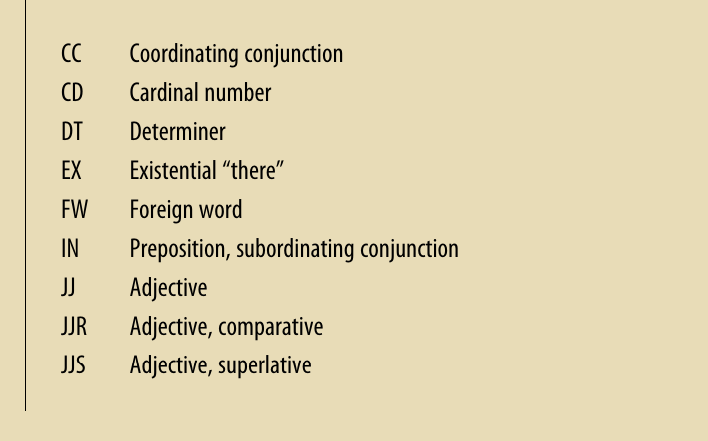

In [84]:
text = word_tokenize("The dust was thick so he had to dust")
pos_tag(text)

[('The', 'DT'),
 ('dust', 'NN'),
 ('was', 'VBD'),
 ('thick', 'RB'),
 ('so', 'RB'),
 ('he', 'PRP'),
 ('had', 'VBD'),
 ('to', 'TO'),
 ('dust', 'VB')]

In [89]:
sentences = [
    "Google is one of the best companies in the world.",
    "I constantly google myself to see what I'm up to."
]

nouns = ["NN", "NNS", "NNP", "NNPS"]

for sentence in sentences:
    for word, tag in pos_tag(word_tokenize(sentence)):
        if word.lower() == "google" and tag in nouns:
            print(sentence)

Google is one of the best companies in the world.
